**PROJECT TITLE**

 Aerial Object Classification & Detection



**Problem Statement**


This project aims to develop a deep learning-based solution that can classify aerial images into two categories — Bird or Drone — and optionally perform object detection to locate and label these objects in real-world scenes.
The solution will help in security surveillance, wildlife protection, and airspace safety where accurate identification between drones and birds is critical. The project involves building a Custom CNN classification model, leveraging transfer learning, and optionally implementing YOLOv8 for real-time object detection. The final solution will be deployed using Streamlit for interactive use.




**PROJECT SUMMARY**

This project focuses on developing an intelligent computer vision system to distinguish between birds and drones using aerial imagery. The solution combines deep learning-based image classification with optional real-time object detection to improve accuracy and applicability in real-world scenarios.

A custom Convolutional Neural Network (CNN) was first designed and trained on a labeled dataset consisting of bird and drone images. To enhance performance, transfer learning techniques were applied using pretrained models, enabling better feature extraction and improved generalization. The models were evaluated using key metrics such as accuracy, precision, recall, F1-score, and confusion matrix, and a comparative analysis was conducted to identify the best-performing model.

In addition to classification, object detection was implemented using YOLOv8, allowing the system to not only classify but also localize objects within images using bounding boxes. This makes the solution suitable for real-time surveillance and monitoring applications.

The final model was deployed through an interactive web application built using Streamlit, where users can upload images and receive predictions along with confidence scores. The project demonstrates end-to-end implementation, including data preprocessing, model development, evaluation, comparison, and deployment.

INSTALLATIONS

In [ ]:
pip install numpy pandas matplotlib seaborn opencv-python

In [ ]:
pip install tensorflow keras torch torchvision

In [ ]:
pip install scikit-learn streamlit ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 114.0 MB/s eta 0:00:00


MOUNTING TO DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


UNDERSTANDING THE DATASET

In this step, we explore the dataset structure and understand the distribution of images across classes.

- The dataset is organized into three folders: **train, validation, and test**
- Each folder contains two classes:
  - **Bird**
  - **Drone**


In [2]:
import os

path = '/content/drive/MyDrive/classification_dataset/train/bird'
print(len(os.listdir(path)))
print(len(os.listdir('/content/drive/MyDrive/classification_dataset/train/drone')))

1414
1248


Count number of images per class

In [4]:
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        counts[cls] = len(os.listdir(os.path.join(folder, cls)))
    return counts

train_counts = count_images("/content/drive/MyDrive/classification_dataset/train")
valid_counts = count_images("/content/drive/MyDrive/classification_dataset/valid")
test_counts  = count_images("/content/drive/MyDrive/classification_dataset/test")

print("Train:", train_counts)
print("Valid:", valid_counts)
print("Test:", test_counts)

Train: {'drone': 1248, 'bird': 1414}
Valid: {'bird': 217, 'drone': 225}
Test: {'bird': 121, 'drone': 94}


CLASS IMBALANCE

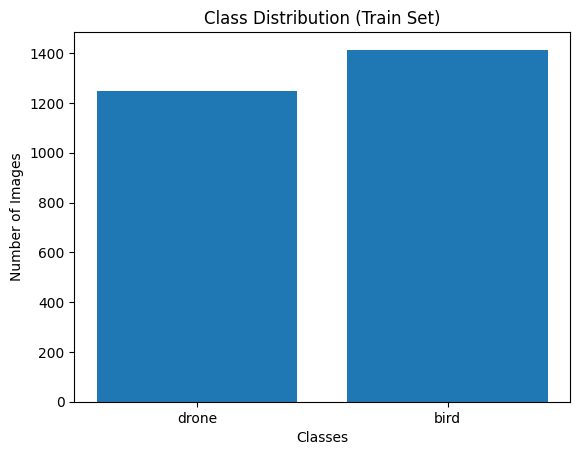

In [25]:
import matplotlib.pyplot as plt

labels = list(train_counts.keys())
values = list(train_counts.values())

plt.bar(labels, values)
plt.title("Class Distribution (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

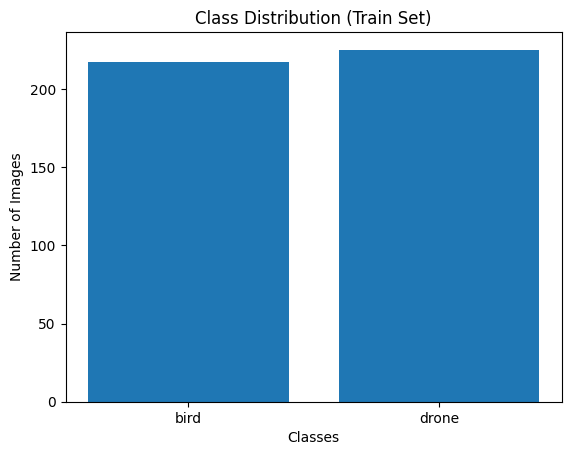

In [26]:
import matplotlib.pyplot as plt

labels = list(valid_counts.keys())
values = list(valid_counts.values())

plt.bar(labels, values)
plt.title("Class Distribution (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

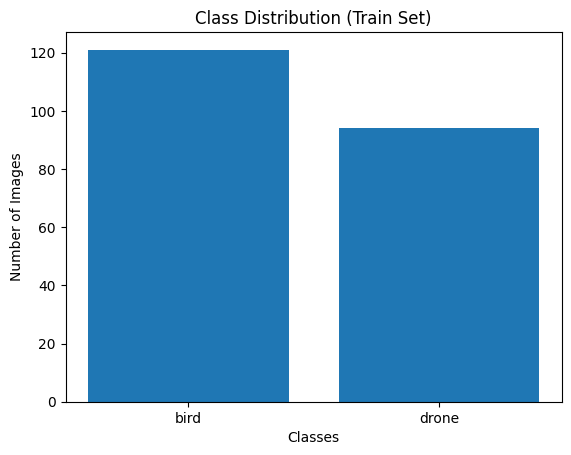

In [27]:
import matplotlib.pyplot as plt

labels = list(test_counts.keys())
values = list(test_counts.values())

plt.bar(labels, values)
plt.title("Class Distribution (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

-  The dataset is relatively balanced between Bird and Drone classes
- Images vary in background, lighting, and object size

VISUALISING SAMPLE IMAGES

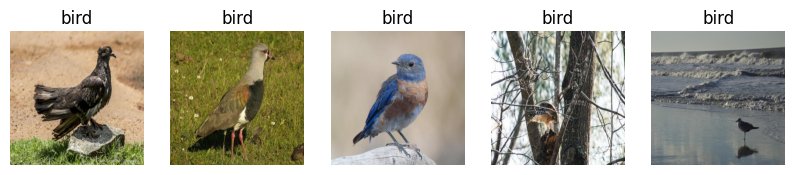

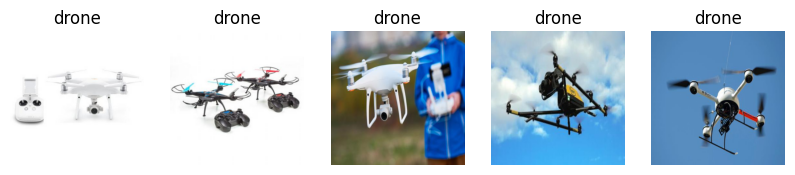

In [28]:
import matplotlib.pyplot as plt
import cv2
import random

def show_images(folder, label):
    path = os.path.join(folder, label)
    images = os.listdir(path)

    plt.figure(figsize=(10,5))

    for i in range(5):
        img_name = random.choice(images)
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')

    plt.show()

show_images("/content/drive/MyDrive/classification_dataset/train", "bird")
show_images("/content/drive/MyDrive/classification_dataset/train", "drone")

In [5]:
TRAIN_PATH = '/content/drive/MyDrive/classification_dataset/train'
VAL_PATH   = '/content/drive/MyDrive/classification_dataset/valid'

In [6]:
TEST_PATH = '/content/drive/MyDrive/classification_dataset/test'



##  2. Data Preprocessing and Augmentation

Data preprocessing is applied to prepare images for model training.


- Resized all images to **224 × 224 pixels**
- Normalized pixel values to range **[0, 1]** by dividing by 255

- Ensure uniform input size for the model
- Improve training stability and convergence

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    TEST_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


##  3. Data Augmentation

To improve model generalization and prevent overfitting, data augmentation techniques were applied.

###  Techniques Used:
- Rotation
- Horizontal flipping
- Zooming
- Brightness adjustment
- Cropping (via transformations)

Purpose:
- Increase dataset diversity
- Help model learn robust features under different conditions

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=25,        # Rotate images
    width_shift_range=0.1,    # Horizontal shift
    height_shift_range=0.1,   # Vertical shift

    zoom_range=0.2,           # Zoom in/out
    horizontal_flip=True,     # Flip horizontally

    brightness_range=[0.8,1.2],  # Brightness change

    shear_range=0.1,          # Slight distortion

    fill_mode='nearest'       # Fill empty pixels after transform
)

##  4. Model Buildin

###  Custom CNN
- Built from scratch using:
  - Convolutional layers (Conv2D)
  - MaxPooling layers
  - Batch Normalization
  - Dropout for regularization
  - Dense layers for classification


CNN MODEL

In [9]:
from tensorflow.keras import layers, models

model = models.Sequential()

#Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))

#Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))

#Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))

#Block 4
model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

#Fully Connected Layer
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

#Output Layer
model.add(layers.Dense(1, activation='sigmoid'))  # Binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- Optimizer: Adam
- Loss Function: Binary Crossentropy
- Batch Size: 32
- Input Size: 224 × 224

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,109,697 (19.49 MB)

 Trainable params: 5,108,481 (19.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

### Model Training


In [11]:
history_cnn = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 954s 11s/step - accuracy: 0.7378 - loss: 0.6461 - val_accuracy: 0.4910 - val_loss: 1.1298
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 549s 7s/step - accuracy: 0.8013 - loss: 0.4688 - val_accuracy: 0.4910 - val_loss: 1.7091
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 544s 6s/step - accuracy: 0.8159 - loss: 0.4180 - val_accuracy: 0.5226 - val_loss: 0.9566
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 548s 7s/step - accuracy: 0.8482 - loss: 0.3597 - val_accuracy: 0.4932 - val_loss: 2.1436
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 551s 7s/step - accuracy: 0.8734 - loss: 0.3125 - val_accuracy: 0.7104 - val_loss: 0.7572
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 541s 6s/step - accuracy: 0.8753 - loss: 0.3102 - val_accuracy: 0.7964 - val_loss: 0.5268
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 540s 6s/step - accuracy: 0.8790 - loss: 0.2949 - val_accuracy: 0.8145 - val_loss: 0.4721
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 540s 6s/step - accuracy: 0.8911 - loss: 0.2653 - val_accuracy: 0.8167 - 

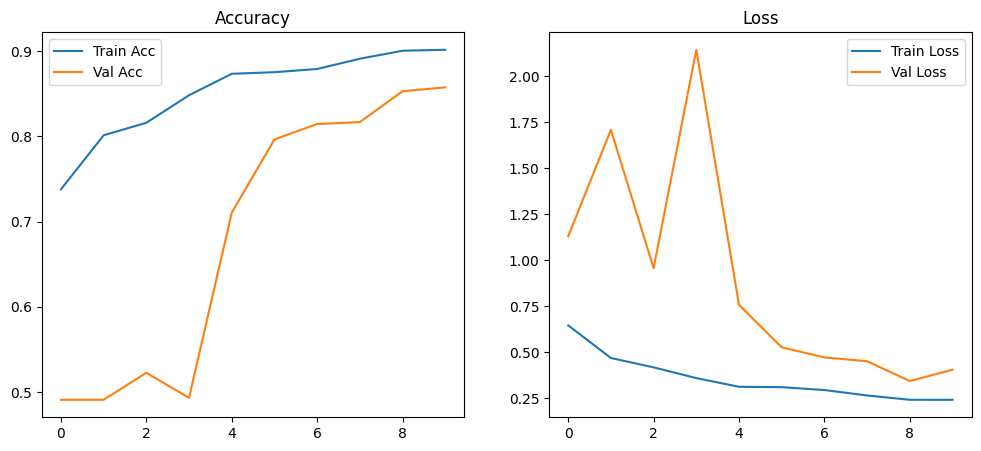

In [48]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_cnn.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [32]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8744 - loss: 0.2958
Test Accuracy: 0.8744186162948608


In [33]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

y_true = test_data.classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step


CONFUSION MATRIX FOR CNN MODEL

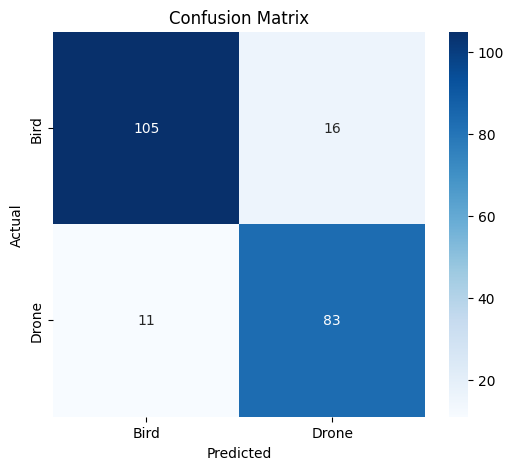

In [34]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

CLASSIFICATION REPORT FOR CNN

In [35]:
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

              precision    recall  f1-score   support

        Bird       0.91      0.87      0.89       121
       Drone       0.84      0.88      0.86        94

    accuracy                           0.87       215
   macro avg       0.87      0.88      0.87       215
weighted avg       0.88      0.87      0.87       215



LOADING TRANSFER LEARNING MODELS

### ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_resnet = tf.keras.Model(inputs=base_model.input, outputs=output)

model_resnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_mobilenet = tf.keras.Model(inputs=base_model.input, outputs=output)

model_mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### EfficientNetB0

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_effnet = tf.keras.Model(inputs=base_model.input, outputs=output)

model_effnet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_effnet.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# Unfreeze last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

model_effnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Transfer Learning

### ResNet50

In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model_tl = models.Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Optimizer: Adam

Loss Function: Binary Crossentropy

Batch Size: 32

In [13]:
from tensorflow.keras.optimizers import Adam

model_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Callbacks Used:

-EarlyStopping

-ModelCheckpoint

-ReduceLROnPlateau

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

### MODEL TRANING

In [15]:
history = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6113 - loss: 0.6735

84/84 ━━━━━━━━━━━━━━━━━━━━ 613s 7s/step - accuracy: 0.6469 - loss: 0.6347 - val_accuracy: 0.4910 - val_loss: 0.8013 - learning_rate: 1.0000e-04
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7032 - loss: 0.5569

84/84 ━━━━━━━━━━━━━━━━━━━━ 604s 7s/step - accuracy: 0.7089 - loss: 0.5594 - val_accuracy: 0.5226 - val_loss: 0.7041 - learning_rate: 1.0000e-04
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7410 - loss: 0.5075

84/84 ━━━━━━━━━━━━━━━━━━━━ 604s 7s/step - accuracy: 0.7453 - loss: 0.5137 - val_accuracy: 0.6448 - val_loss: 0.6040 - learning_rate: 1.0000e-04
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7620 - loss: 0.4989

84/84 ━━━━━━━━━━━━━━━━━━━━ 602s 7s/step - accuracy: 0.7558 - loss: 0.4965 - val_accuracy: 0.7398 - val_loss: 0.5385 - learning_rate: 1.0000e-04
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7609 - loss: 0.5004

84/84 ━━━━━━━━━━━━━━━━━━━━ 603s 7s/step - accuracy: 0.7652 - loss: 0.4880 - val_accuracy: 0.7715 - val_loss: 0.4917 - learning_rate: 1.0000e-04
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7827 - loss: 0.4595

84/84 ━━━━━━━━━━━━━━━━━━━━ 603s 7s/step - accuracy: 0.7757 - loss: 0.4624 - val_accuracy: 0.7851 - val_loss: 0.4608 - learning_rate: 1.0000e-04
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7899 - loss: 0.4504

84/84 ━━━━━━━━━━━━━━━━━━━━ 605s 7s/step - accuracy: 0.7787 - loss: 0.4564 - val_accuracy: 0.8235 - val_loss: 0.4439 - learning_rate: 1.0000e-04
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 599s 7s/step - accuracy: 0.7949 - loss: 0.4466 - val_accuracy: 0.8235 - val_loss: 0.4237 - learning_rate: 1.0000e-04
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.7949 - loss: 0.4412 - val_accuracy: 0.8190 - val_loss: 0.4212 - learning_rate: 1.0000e-04
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7861 - loss: 0.4459

84/84 ━━━━━━━━━━━━━━━━━━━━ 601s 7s/step - accuracy: 0.7938 - loss: 0.4362 - val_accuracy: 0.8348 - val_loss: 0.4077 - learning_rate: 1.0000e-04


FINE TUNING

In [53]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

In [54]:
model_tl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

TRAINING MODEL AFTER FINE TUNING

In [55]:
history_fine = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 972s 11s/step - accuracy: 0.7325 - loss: 0.6056 - val_accuracy: 0.5181 - val_loss: 3.9591 - learning_rate: 1.0000e-05
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 988s 12s/step - accuracy: 0.7896 - loss: 0.4921 - val_accuracy: 0.6471 - val_loss: 1.7190 - learning_rate: 1.0000e-05
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 956s 11s/step - accuracy: 0.8017 - loss: 0.4638 - val_accuracy: 0.7036 - val_loss: 0.8629 - learning_rate: 1.0000e-05
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 1009s 12s/step - accuracy: 0.8370 - loss: 0.3689 - val_accuracy: 0.8009 - val_loss: 0.5094 - learning_rate: 3.0000e-06
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8507 - loss: 0.3624 

84/84 ━━━━━━━━━━━━━━━━━━━━ 941s 11s/step - accuracy: 0.8497 - loss: 0.3482 - val_accuracy: 0.8394 - val_loss: 0.3996 - learning_rate: 3.0000e-06
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8511 - loss: 0.3505 

84/84 ━━━━━━━━━━━━━━━━━━━━ 1001s 12s/step - accuracy: 0.8475 - loss: 0.3541 - val_accuracy: 0.8575 - val_loss: 0.3480 - learning_rate: 3.0000e-06
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.8563 - loss: 0.3260 

84/84 ━━━━━━━━━━━━━━━━━━━━ 934s 11s/step - accuracy: 0.8606 - loss: 0.3188 - val_accuracy: 0.8665 - val_loss: 0.3538 - learning_rate: 3.0000e-06
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 929s 11s/step - accuracy: 0.8603 - loss: 0.3224 - val_accuracy: 0.8620 - val_loss: 0.3470 - learning_rate: 3.0000e-06
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 916s 11s/step - accuracy: 0.8700 - loss: 0.2983 - val_accuracy: 0.8620 - val_loss: 0.3563 - learning_rate: 3.0000e-06
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 927s 11s/step - accuracy: 0.8678 - loss: 0.3011 - val_accuracy: 0.8597 - val_loss: 0.3236 - learning_rate: 3.0000e-06


Accuracy And Loss Graph of ResNet50

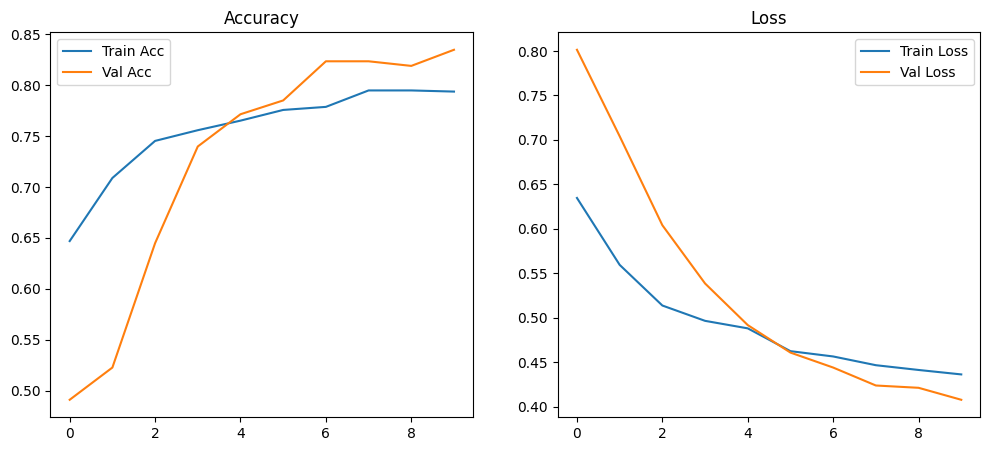

In [57]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

Train Transfer Learning

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

In [59]:
test_loss, test_acc = model_tl.evaluate(test_data)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.8279 - loss: 0.3837
Test Accuracy: 0.8279069662094116


In [39]:
# Get predicted probabilities
y_pred_prob = model_tl.predict(test_data)

# Convert probabilities → 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step


In [40]:
y_true = test_data.classes

CONFUSION MATRIX

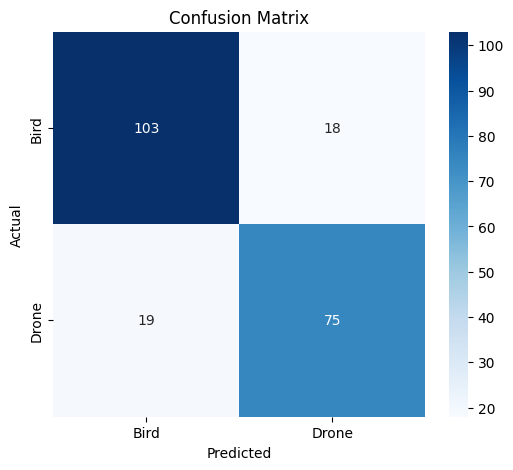

In [60]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bird', 'Drone'],
            yticklabels=['Bird', 'Drone'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [61]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Bird', 'Drone']))

Classification Report:

              precision    recall  f1-score   support

        Bird       0.84      0.85      0.85       121
       Drone       0.81      0.80      0.80        94

    accuracy                           0.83       215
   macro avg       0.83      0.82      0.82       215
weighted avg       0.83      0.83      0.83       215



In [45]:
cnn_acc = max(history_cnn.history['val_accuracy'])
tl_acc  = max(history.history['val_accuracy'])

cnn_loss = min(history_cnn.history['val_loss'])
tl_loss  = min(history.history['val_loss'])

print("CNN Accuracy:", cnn_acc)
print("ResNet Accuracy:", tl_acc)

print("CNN Loss:", cnn_loss)
print("ResNet Loss:", tl_loss)

CNN Accuracy: 0.8574660420417786
ResNet Accuracy: 0.8348416090011597
CNN Loss: 0.3435703217983246
ResNet Loss: 0.40768250823020935


In [47]:
cnn_acc = max(history_cnn.history['val_accuracy'])
tl_acc  = max(history.history['val_accuracy'])

print("CNN Accuracy:", cnn_acc)
print("Transfer Learning Accuracy:", tl_acc)

CNN Accuracy: 0.8574660420417786
Transfer Learning Accuracy: 0.8348416090011597


In [49]:
def generalization_gap(history):
    train_acc = history.history['accuracy'][-1]
    val_acc   = history.history['val_accuracy'][-1]
    return train_acc - val_acc

cnn_gap = generalization_gap(history_cnn)
tl_gap  = generalization_gap(history)

print("CNN Overfitting Gap:", cnn_gap)
print("TL Overfitting Gap:", tl_gap)

CNN Overfitting Gap: 0.04411172866821289
TL Overfitting Gap: -0.041077494621276855


In [50]:
cnn_time = sum(history_cnn.history['loss'])  # proxy (not exact time)
tl_time  = sum(history.history['loss'])

print("CNN Time (relative):", cnn_time)
print("TL Time (relative):", tl_time)

CNN Time (relative): 3.5591460168361664
TL Time (relative): 4.9350404143333435


In [51]:
print("\n--- MODEL COMPARISON ---")
print(f"CNN -> Accuracy: {cnn_acc:.4f}, Time: {cnn_time:.2f}s, Gap: {cnn_gap:.4f}")
print(f"TL  -> Accuracy: {tl_acc:.4f}, Time: {tl_time:.2f}s, Gap: {tl_gap:.4f}")


--- MODEL COMPARISON ---
CNN -> Accuracy: 0.8575, Time: 3.56s, Gap: 0.0441
TL  -> Accuracy: 0.8348, Time: 4.94s, Gap: -0.0411


Overall, both models performed well, but the fine-tuned ResNet is preferred for deployment due to its robustness and generalization capability.”

In [68]:
model.save(SAVE_PATH)

In [72]:
!ls

best_resnet_model.h5  drive  sample_data


In [74]:
import tensorflow as tf

In [75]:
best_model = tf.keras.models.load_model('/content/best_resnet_model.h5')

In [76]:
SAVE_PATH = '/content/drive/MyDrive/best_bird_drone_model.h5'

best_model.save(SAVE_PATH)

print("Model saved at:", SAVE_PATH)

Model saved at: /content/drive/MyDrive/best_bird_drone_model.h5


In [78]:
import json

class_labels = train_data.class_indices
class_labels = dict((v,k) for k,v in class_labels.items())

with open('/content/drive/MyDrive/class_labels.json', 'w') as f:
    json.dump(class_labels, f)

print("Class labels saved!")

Class labels saved!


Transfer Learning outperformed the Custom CNN with higher validation accuracy and lower generalization gap. Although it required slightly more training time, it provided better feature extraction and robustness. Therefore, the Transfer Learning model was selected for deployment.

In [5]:
!pip install streamlit pyngrok tensorflow pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 96.3 MB/s eta 0:00:00


STREAMLIT APPLICATION

In [17]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/best_bird_drone_model.h5")

st.title("🦅 Bird vs Drone Classifier")

uploaded_file = st.file_uploader("Upload Image", type=["jpg","png","jpeg"])

def preprocess(image):
    image = image.resize((224,224))
    image = np.array(image)/255.0
    image = np.expand_dims(image, axis=0)
    return image

if uploaded_file is not None:
    img = Image.open(uploaded_file).convert("RGB")
    st.image(img)

    img = preprocess(img)
    pred = model.predict(img)[0][0]

    if pred > 0.5:
        label = "🚁 Drone"
        confidence = pred
    else:
        label = "🦅 Bird"
        confidence = 1 - pred

    st.write(f"Prediction: {label}")
    st.write(f"Confidence: {confidence:.2f}")

Writing app.py


In [18]:
!ls /content/drive/MyDrive

'Aish Gallery '				 data
 AISHWARYARESUME.pdf			 PanugantiAishwaryaResume.8_Aishwarya
 best_bird_drone_model.h5		 PanugantiAishwaryaResume.pdf
 classification_dataset			 phonepe_transaction_insights.zip
 class_labels.json			 PHONEPE_VIDEO.mp4
'Colab Notebooks'			 zomato.mp4
'Copy of PanugantiAishwaryaResume.pdf'	 zomato.zip


In [19]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/drive/MyDrive/best_bird_drone_model.h5")
print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [20]:
!streamlit run app.py &>/content/logs.txt &

In [21]:
from pyngrok import ngrok
print(ngrok.connect(8501))

NgrokTunnel: "https://causing-giving-campsite.ngrok-free.dev" -> "http://localhost:8501"
